# 01 — EDA: PCOS Symptoms Dataset

Objective: Understand the structure, quality, and patterns in the symptom-based dataset before feature engineering.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore")

# ── Style ──────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12, "axes.titleweight": "bold"})


## 1. Load & Initial Inspection

In [2]:
df = pd.read_csv("../data/raw/PCOS_symptoms.csv")

# ── 1: strip leading/trailing spaces from column names ──
df.columns = df.columns.str.strip()

print(f"Shape: {df.shape}")
print(f"Columns ({len(df.columns)}):")
for c in df.columns:
    print(f"  {c!r}")


Shape: (684, 33)
Columns (33):
  'PCOS'
  'Family_background'
  'LH_hormone'
  'FSH_hormone'
  'Diabetes_measurment'
  'TSH_hormone'
  'Prolactin_hormone'
  'Hemoglobin_level'
  'Cyst_ovary'
  'Diagnosis_age'
  'Overweight'
  'Period_type'
  'Hormonal_imbalance'
  'Gain_weight'
  'Excess_facial_hair'
  'Excess_body_hair'
  'Dark_area'
  'Pimple_face'
  'Hormonal_acne_face'
  'Blood_pressure'
  'Fast_food'
  'Losing_hair'
  'Ex_pain_abdominal'
  'Mood_swing_period'
  'Mood_swing_normal'
  'Craving_PT'
  'Depress'
  'Mental_stress'
  'Insomnia'
  'Slow_activity'
  'Weight(kg)'
  'Height(m)'
  'BMI(kg/m*m)'


In [3]:
df.head()

,PCOS,Family_background,LH_hormone,FSH_hormone,Diabetes_measurment,TSH_hormone,Prolactin_hormone,Hemoglobin_level,Cyst_ovary,Diagnosis_age,...,Mood_swing_period,Mood_swing_normal,Craving_PT,Depress,Mental_stress,Insomnia,Slow_activity,Weight(kg),Height(m),BMI(kg/m*m)
0,1,Yes,Normal,Abnormal,Abnormal,Abnormal,Normal,Normal,Yes,Youth,...,High,High,High,Yes,Yes,No,Yes,60.0,1.5494,25.0
1,1,I do not know,I do not know,I do not know,I do not know,I do not know,I do not know,I do not know,i do not know,adult,...,High,High,High,No,No,Yes,Yes,34.0,1.5494,14.2
2,0,I do not know,I do not know,I do not know,I do not know,I do not know,I do not know,I do not know,i do not know,adult,...,High,Medium,High,Yes,Yes,Yes,Yes,60.0,1.6510,22.0
3,1,No,Normal,Normal,Normal,Normal,Normal,Normal,No,Youth,...,Extreme,Medium,Medium,Yes,Yes,No,Yes,65.0,1.7018,22.4
4,0,I do not know,I do not know,I do not know,I do not know,I do not know,I do not know,I do not know,i do not know,adult,...,Normal,Normal,Normal,No,No,No,No,47.0,1.5240,20.2


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 684 entries, 0 to 683
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PCOS                 684 non-null    int64  
 1   Family_background    684 non-null    object 
 2   LH_hormone           684 non-null    object 
 3   FSH_hormone          684 non-null    object 
 4   Diabetes_measurment  684 non-null    object 
 5   TSH_hormone          684 non-null    object 
 6   Prolactin_hormone    684 non-null    object 
 7   Hemoglobin_level     684 non-null    object 
 8   Cyst_ovary           684 non-null    object 
 9   Diagnosis_age        684 non-null    object 
 10  Overweight           684 non-null    object 
 11  Period_type          684 non-null    object 
 12  Hormonal_imbalance   684 non-null    object 
 13  Gain_weight          684 non-null    object 
 14  Excess_facial_hair   684 non-null    object 
 15  Excess_body_hair     684 non-null    obj

In [5]:
df.describe()


,PCOS,Weight(kg),Height(m),BMI(kg/m*m)
count,684.000000,684.000000,684.000000,684.000000
mean,0.761696,65.291959,1.577096,25.838450
std,0.426358,14.355525,0.106071,5.644614
min,0.000000,34.000000,0.000000,0.000000
25%,1.000000,55.000000,1.549400,22.000000
50%,1.000000,65.000000,1.574800,25.800000
75%,1.000000,74.000000,1.625600,29.500000
max,1.000000,130.000000,1.993900,51.200000


## 2. Dataset Quality Summary

In [6]:
# ── 2: detect height/BMI = 0 (impossible values) ──────
invalid_height = (df["Height(m)"] == 0).sum()
invalid_bmi    = (df["BMI(kg/m*m)"] == 0).sum()

# ── 3: detect dirty category value '2' in Hormonal_imbalance
dirty_hormonal = (df["Hormonal_imbalance"] == "2").sum()

# ── Count 'I do not know' per column ──────────────────────
cat_cols = df.select_dtypes(include="object").columns.tolist()
idk_counts = {
    col: df[col].str.lower().str.contains("do not know", na=False).sum()
    for col in cat_cols
}
idk_counts = {k: v for k, v in idk_counts.items() if v > 0}

summary = {
    "Rows": len(df),
    "Columns": len(df.columns),
    "Numerical features": len(df.select_dtypes(include="number").columns),
    "Categorical features": len(cat_cols),
    "Total missing values": df.isnull().sum().sum(),
    "Rows with Height=0 (invalid)": invalid_height,
    "Rows with BMI=0 (invalid)": invalid_bmi,
    "'Hormonal_imbalance' dirty value '2'": dirty_hormonal,
}

print("=" * 50)
print("DATASET QUALITY SUMMARY")
print("=" * 50)
for k, v in summary.items():
    flag = " ⚠️" if v > 0 and k != "Rows" and k != "Columns" and "features" not in k else ""
    print(f"  {k:<45} {v}{flag}")

print()
print("'I do not know' counts per column:")
for col, cnt in idk_counts.items():
    pct = cnt / len(df) * 100
    print(f"  {col:<30} {cnt:>4}  ({pct:.1f}%)")


DATASET QUALITY SUMMARY
  Rows                                          684
  Columns                                       33
  Numerical features                            4
  Categorical features                          29
  Total missing values                          0
  Rows with Height=0 (invalid)                  2 ⚠️
  Rows with BMI=0 (invalid)                     2 ⚠️
  'Hormonal_imbalance' dirty value '2'          50 ⚠️

'I do not know' counts per column:
  Family_background               148  (21.6%)
  LH_hormone                      221  (32.3%)
  FSH_hormone                     219  (32.0%)
  Diabetes_measurment             179  (26.2%)
  TSH_hormone                     210  (30.7%)
  Prolactin_hormone               252  (36.8%)
  Hemoglobin_level                213  (31.1%)
  Cyst_ovary                      235  (34.4%)


## 3. Data Cleaning

In [7]:
# ── Drop rows with Height=0 / BMI=0 ──────────────────────
mask_invalid = (df["Height(m)"] == 0) | (df["BMI(kg/m*m)"] == 0)
print(f"Dropping {mask_invalid.sum()} rows with Height=0 or BMI=0")
df = df[~mask_invalid].reset_index(drop=True)

# ── Fix Hormonal_imbalance: treat '2' as NaN, then mode-fill
df["Hormonal_imbalance"] = df["Hormonal_imbalance"].replace("2", np.nan)
mode_val = df["Hormonal_imbalance"].mode()[0]
df["Hormonal_imbalance"] = df["Hormonal_imbalance"].fillna(mode_val)
print(f"'Hormonal_imbalance' dirty '2' replaced with mode: '{mode_val}'")

# ── Standardise 'i do not know' → 'I do not know' (Cyst_ovary)
df["Cyst_ovary"] = df["Cyst_ovary"].str.strip().str.title().replace(
    {"I Do Not Know": "I do not know"}
)

print(f"\nClean shape: {df.shape}")


Dropping 2 rows with Height=0 or BMI=0
'Hormonal_imbalance' dirty '2' replaced with mode: 'Yes'

Clean shape: (682, 33)


## 4. Class Distribution (Target)

In [8]:
target = "PCOS"
counts = df[target].value_counts()
pcts   = df[target].value_counts(normalize=True) * 100

print("CLASS DISTRIBUTION:")
print(counts.to_string())
print()
print("PERCENTAGE:")
print(pcts.round(2).to_string())

ratio = counts.max() / counts.min()
print(f"\nImbalance ratio: {ratio:.2f}:1")
if ratio > 2:
    print("⚠️  Imbalance detected — plan: SMOTE or class_weight='balanced' in training")


CLASS DISTRIBUTION:
PCOS
1    519
0    163

PERCENTAGE:
PCOS
1    76.1
0    23.9

Imbalance ratio: 3.18:1
⚠️  Imbalance detected — plan: SMOTE or class_weight='balanced' in training


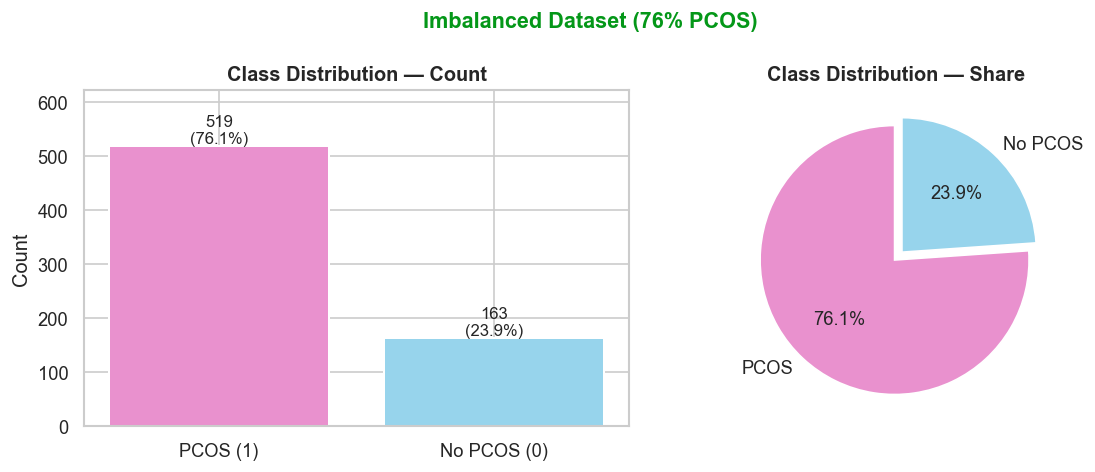

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(["PCOS (1)", "No PCOS (0)"], counts.values,
            color=["#E991CE", "#97D4EC"], edgecolor="white", linewidth=1.2)
for i, (v, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, v + 5, f"{v}\n({p:.1f}%)", ha="center", fontsize=10)
axes[0].set_title("Class Distribution — Count")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, counts.max() * 1.2)

# Pie
axes[1].pie(counts.values, labels=["PCOS", "No PCOS"],
            autopct="%1.1f%%", colors=["#E991CE", "#97D4EC"],
            explode=(0.02, 0.06), startangle=90,
            textprops={"fontsize": 11})
axes[1].set_title("Class Distribution — Share")

plt.suptitle("Imbalanced Dataset (76% PCOS)", fontsize=13, weight="bold", color="#049718")
plt.tight_layout()
plt.show()


## 5. Numerical Feature Distributions

In [10]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop(target).tolist()
cat_cols       = df.select_dtypes(include="object").columns.tolist()

print("Numerical:", numerical_cols)
print("Categorical:", cat_cols)


Numerical: ['Weight(kg)', 'Height(m)', 'BMI(kg/m*m)']
Categorical: ['Family_background', 'LH_hormone', 'FSH_hormone', 'Diabetes_measurment', 'TSH_hormone', 'Prolactin_hormone', 'Hemoglobin_level', 'Cyst_ovary', 'Diagnosis_age', 'Overweight', 'Period_type', 'Hormonal_imbalance', 'Gain_weight', 'Excess_facial_hair', 'Excess_body_hair', 'Dark_area', 'Pimple_face', 'Hormonal_acne_face', 'Blood_pressure', 'Fast_food', 'Losing_hair', 'Ex_pain_abdominal', 'Mood_swing_period', 'Mood_swing_normal', 'Craving_PT', 'Depress', 'Mental_stress', 'Insomnia', 'Slow_activity']


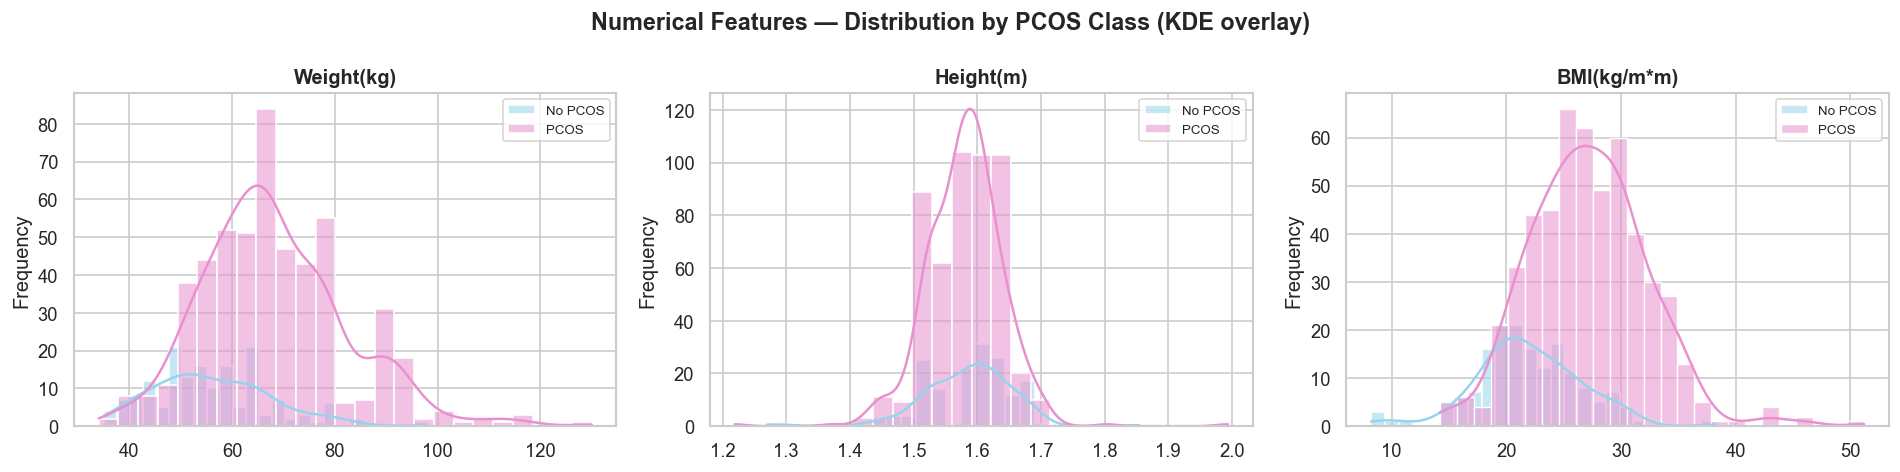

In [11]:
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
palette = sns.color_palette("Set2", len(numerical_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    # Plot separately for each PCOS class with KDE
    for cls, color, label in zip([0, 1], ["#97D4EC", "#E991CE"], ["No PCOS", "PCOS"]):
        subset = df[df[target] == cls][col].dropna()
        sns.histplot(subset, bins=25, kde=True, color=color, alpha=0.55,
                     label=label, ax=ax)
    ax.set_title(f"{col}")
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

for idx in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Numerical Features — Distribution by PCOS Class (KDE overlay)", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


## 6. Outlier Detection (Z-score + Boxplots)

In [12]:
z_scores    = np.abs(stats.zscore(df[numerical_cols].dropna()))
outlier_mask = z_scores > 3
outlier_counts = pd.Series(outlier_mask.sum(axis=0), index=numerical_cols)

print("Outlier counts (|Z| > 3):")
print(outlier_counts[outlier_counts > 0].sort_values(ascending=False).to_string())


Outlier counts (|Z| > 3):
BMI(kg/m*m)    10
Weight(kg)      7
Height(m)       7


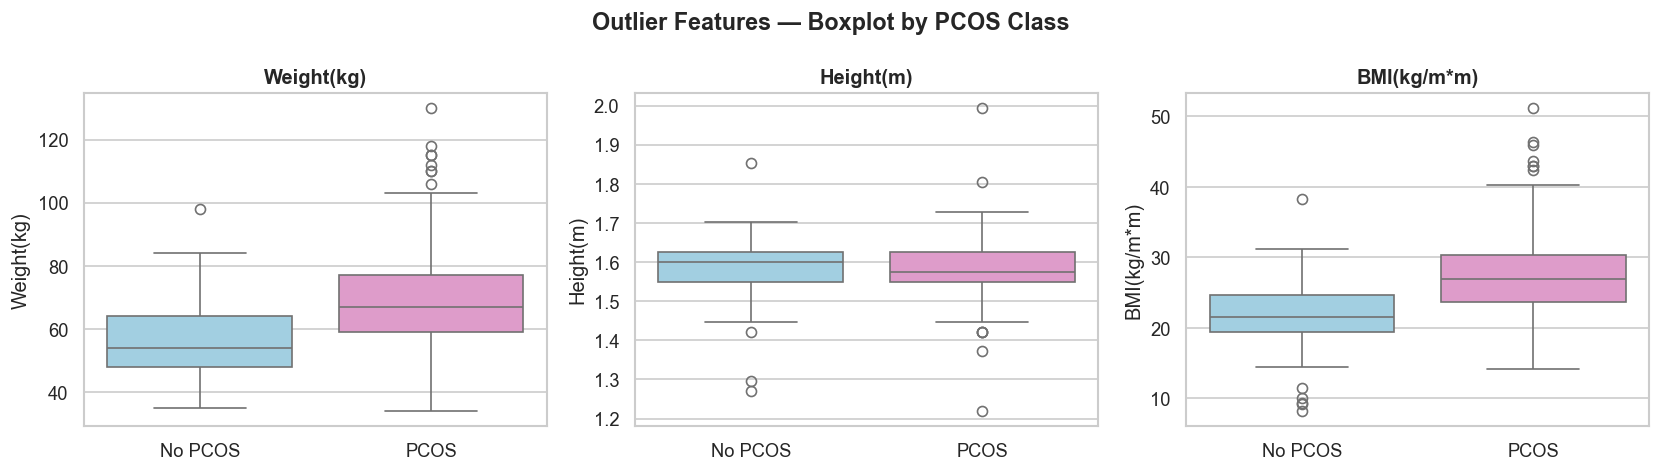

In [13]:
outlier_features = outlier_counts[outlier_counts > 0].index.tolist()

if outlier_features:
    n_cols_b = 3
    n_rows_b = (len(outlier_features) + n_cols_b - 1) // n_cols_b
    fig, axes = plt.subplots(n_rows_b, n_cols_b, figsize=(14, 4 * n_rows_b))
    axes = axes.flatten()

    for idx, col in enumerate(outlier_features):
        sns.boxplot(data=df, y=col, x=target, ax=axes[idx],
                    palette=["#97D4EC", "#E991CE"])
        axes[idx].set_title(col)
        axes[idx].set_xlabel("")
        axes[idx].set_xticklabels(["No PCOS", "PCOS"])

    for idx in range(len(outlier_features), len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle("Outlier Features — Boxplot by PCOS Class", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()


## 7. Categorical Feature Distributions

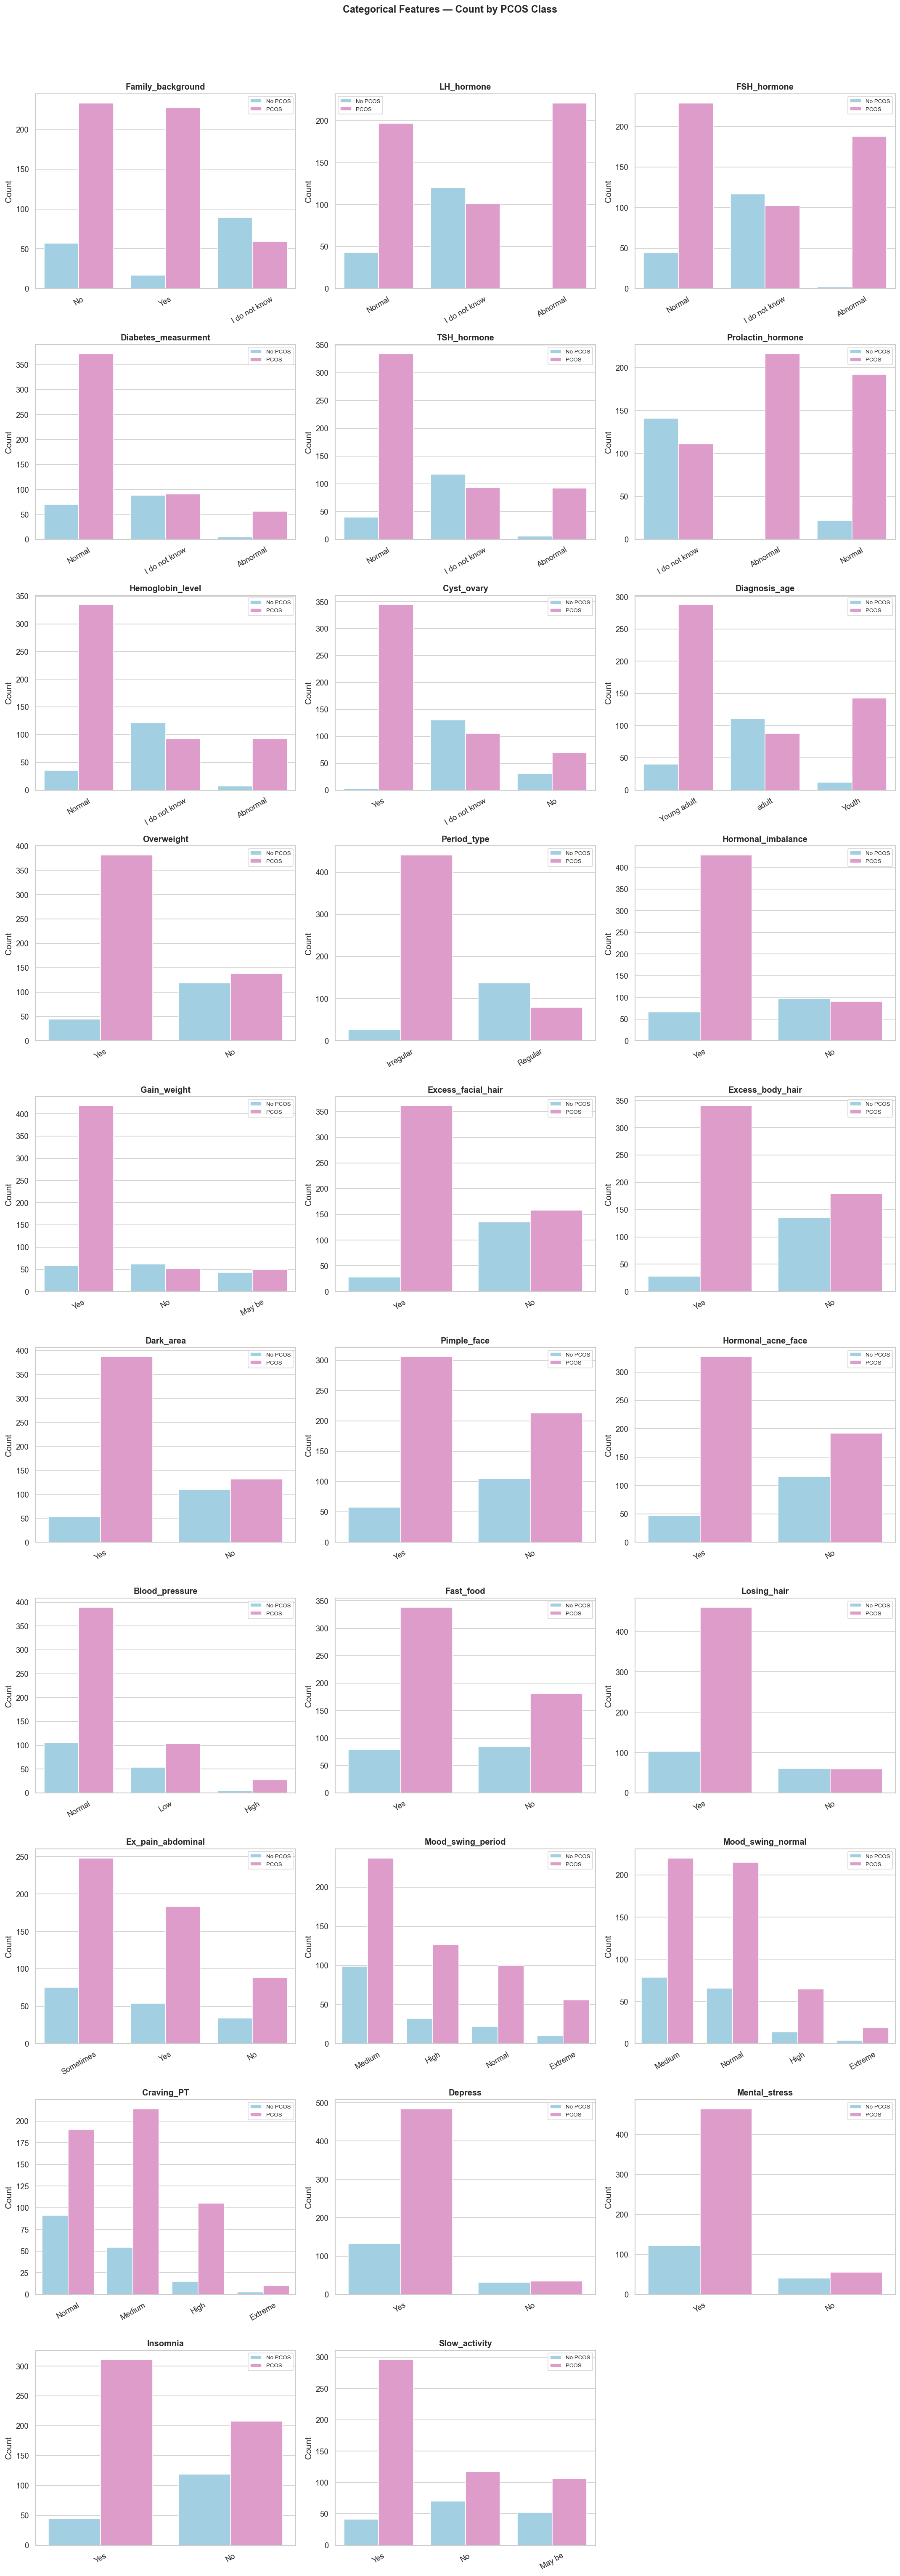

In [14]:
n_cols_c = 3
n_rows_c = (len(cat_cols) + n_cols_c - 1) // n_cols_c

fig, axes = plt.subplots(n_rows_c, n_cols_c, figsize=(18, 5 * n_rows_c))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    ax = axes[idx]
    order = df[col].value_counts().index.tolist()
    sns.countplot(data=df, x=col, hue=target, order=order, ax=ax,
                  palette={0: "#97D4EC", 1: "#E991CE"})
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, ["No PCOS", "PCOS"], fontsize=8)

for idx in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Categorical Features — Count by PCOS Class", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 8. 'I do not know' Analysis

In [15]:
# How frequent is the unknown response per column — and does it correlate with PCOS?
idk_analysis = []
for col in cat_cols:
    is_idk = df[col].str.lower().str.contains("do not know", na=False)
    total_idk = is_idk.sum()
    if total_idk > 0:
        pcos_among_idk = df.loc[is_idk, target].mean() * 100
        idk_analysis.append({
            "Column": col,
            "IDK count": total_idk,
            "IDK %": round(total_idk / len(df) * 100, 1),
            "PCOS rate among IDK %": round(pcos_among_idk, 1),
            "Overall PCOS rate %": round(df[target].mean() * 100, 1),
        })

idk_df = pd.DataFrame(idk_analysis).sort_values("IDK %", ascending=False)
print(idk_df.to_string(index=False))
print()
print("→ If 'PCOS rate among IDK' ≈ overall rate → IDK is random (safe to impute with mode)")
print("→ If much higher/lower → IDK may carry signal (treat as separate category)")
print("→ The overall PCOS rate in the symptoms dataset is 76%. That means if you picked a random person from this dataset, they have a '76%' chance of having PCOS.")


             Column  IDK count  IDK %  PCOS rate among IDK %  Overall PCOS rate %
  Prolactin_hormone        252   37.0                   44.0                 76.1
         Cyst_ovary        235   34.5                   44.7                 76.1
         LH_hormone        221   32.4                   45.7                 76.1
        FSH_hormone        219   32.1                   46.6                 76.1
   Hemoglobin_level        213   31.2                   43.2                 76.1
        TSH_hormone        210   30.8                   44.3                 76.1
Diabetes_measurment        179   26.2                   50.8                 76.1
  Family_background        148   21.7                   39.9                 76.1

→ If 'PCOS rate among IDK' ≈ overall rate → IDK is random (safe to impute with mode)
→ If much higher/lower → IDK may carry signal (treat as separate category)
→ The overall PCOS rate in the symptoms dataset is 76%. That means if you picked a random person from

## 9. Correlation Analysis

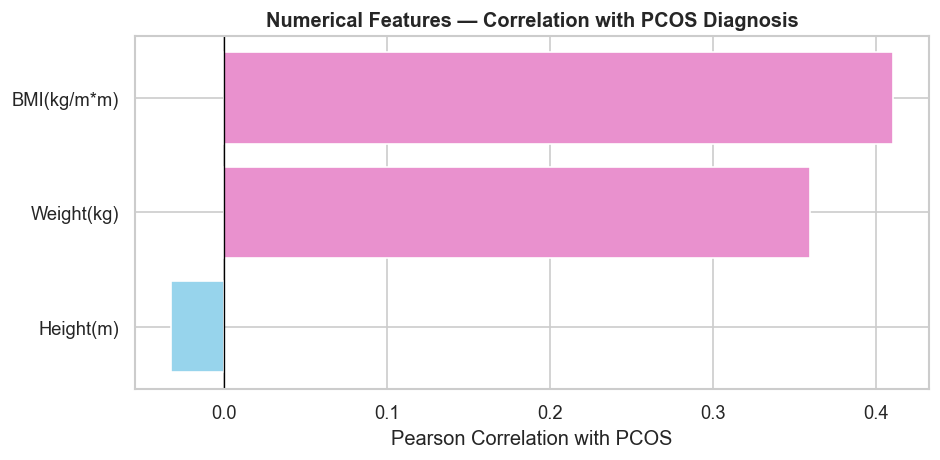

BMI(kg/m*m)    0.410035
Weight(kg)     0.359491
Height(m)     -0.032046


In [16]:
# Numerical correlation with target
corr_series = df[numerical_cols + [target]].corr()[target].drop(target).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#E991CE" if v > 0 else "#97D4EC" for v in corr_series.values]
ax.barh(corr_series.index[::-1], corr_series.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with PCOS")
ax.set_title("Numerical Features — Correlation with PCOS Diagnosis")
plt.tight_layout()
plt.show()

print(corr_series.to_string())


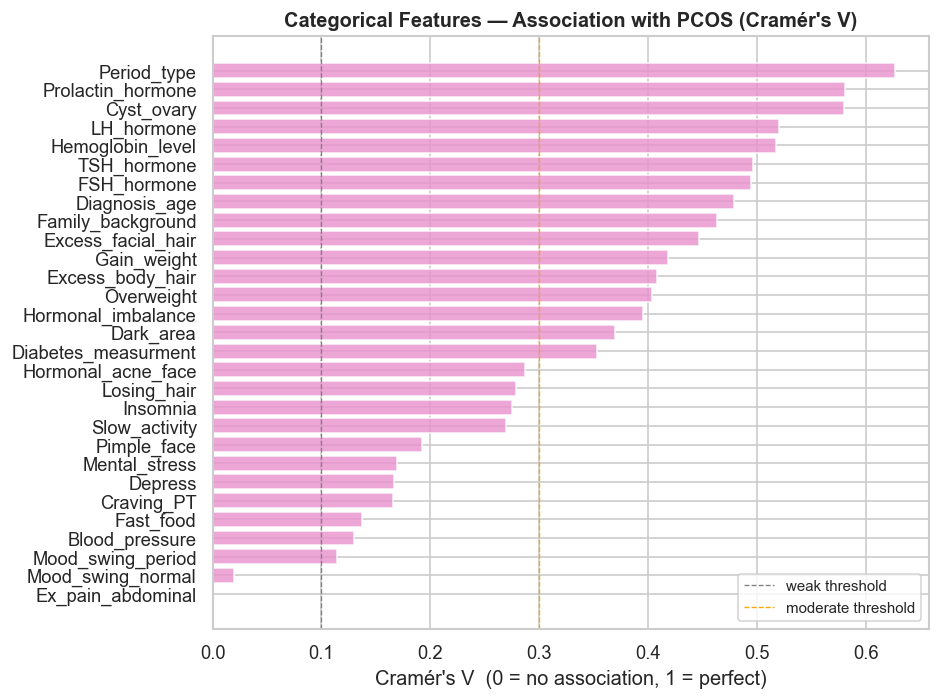

In [17]:
# Cramér's V for categorical features vs PCOS
def cramers_v(x, y):
    cm   = pd.crosstab(x, y)
    chi2 = chi2_contingency(cm)[0]
    n    = cm.sum().sum()
    r, k = cm.shape
    phi2corr = max(0, chi2 / n - ((k-1)*(r-1)) / (n-1))
    rcorr    = r - (r-1)**2 / (n-1)
    kcorr    = k - (k-1)**2 / (n-1)
    denom    = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else 0

cv_results = {}
for col in cat_cols:
    try:
        cv_results[col] = cramers_v(df[col], df[target])
    except Exception:
        cv_results[col] = np.nan

cv_df = pd.DataFrame.from_dict(cv_results, orient="index", columns=["Cramers_V"])           .sort_values("Cramers_V", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(cv_df.index, cv_df["Cramers_V"], color="#E991CE", alpha=0.8)
ax.set_xlabel("Cramér's V  (0 = no association, 1 = perfect)")
ax.set_title("Categorical Features — Association with PCOS (Cramér's V)")
ax.axvline(0.1, color="gray", linestyle="--", linewidth=0.8, label="weak threshold")
ax.axvline(0.3, color="orange", linestyle="--", linewidth=0.8, label="moderate threshold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 10. Feature-vs-Target Conditional Analysis

For high-Cramér's V features: what is the PCOS rate within each category?

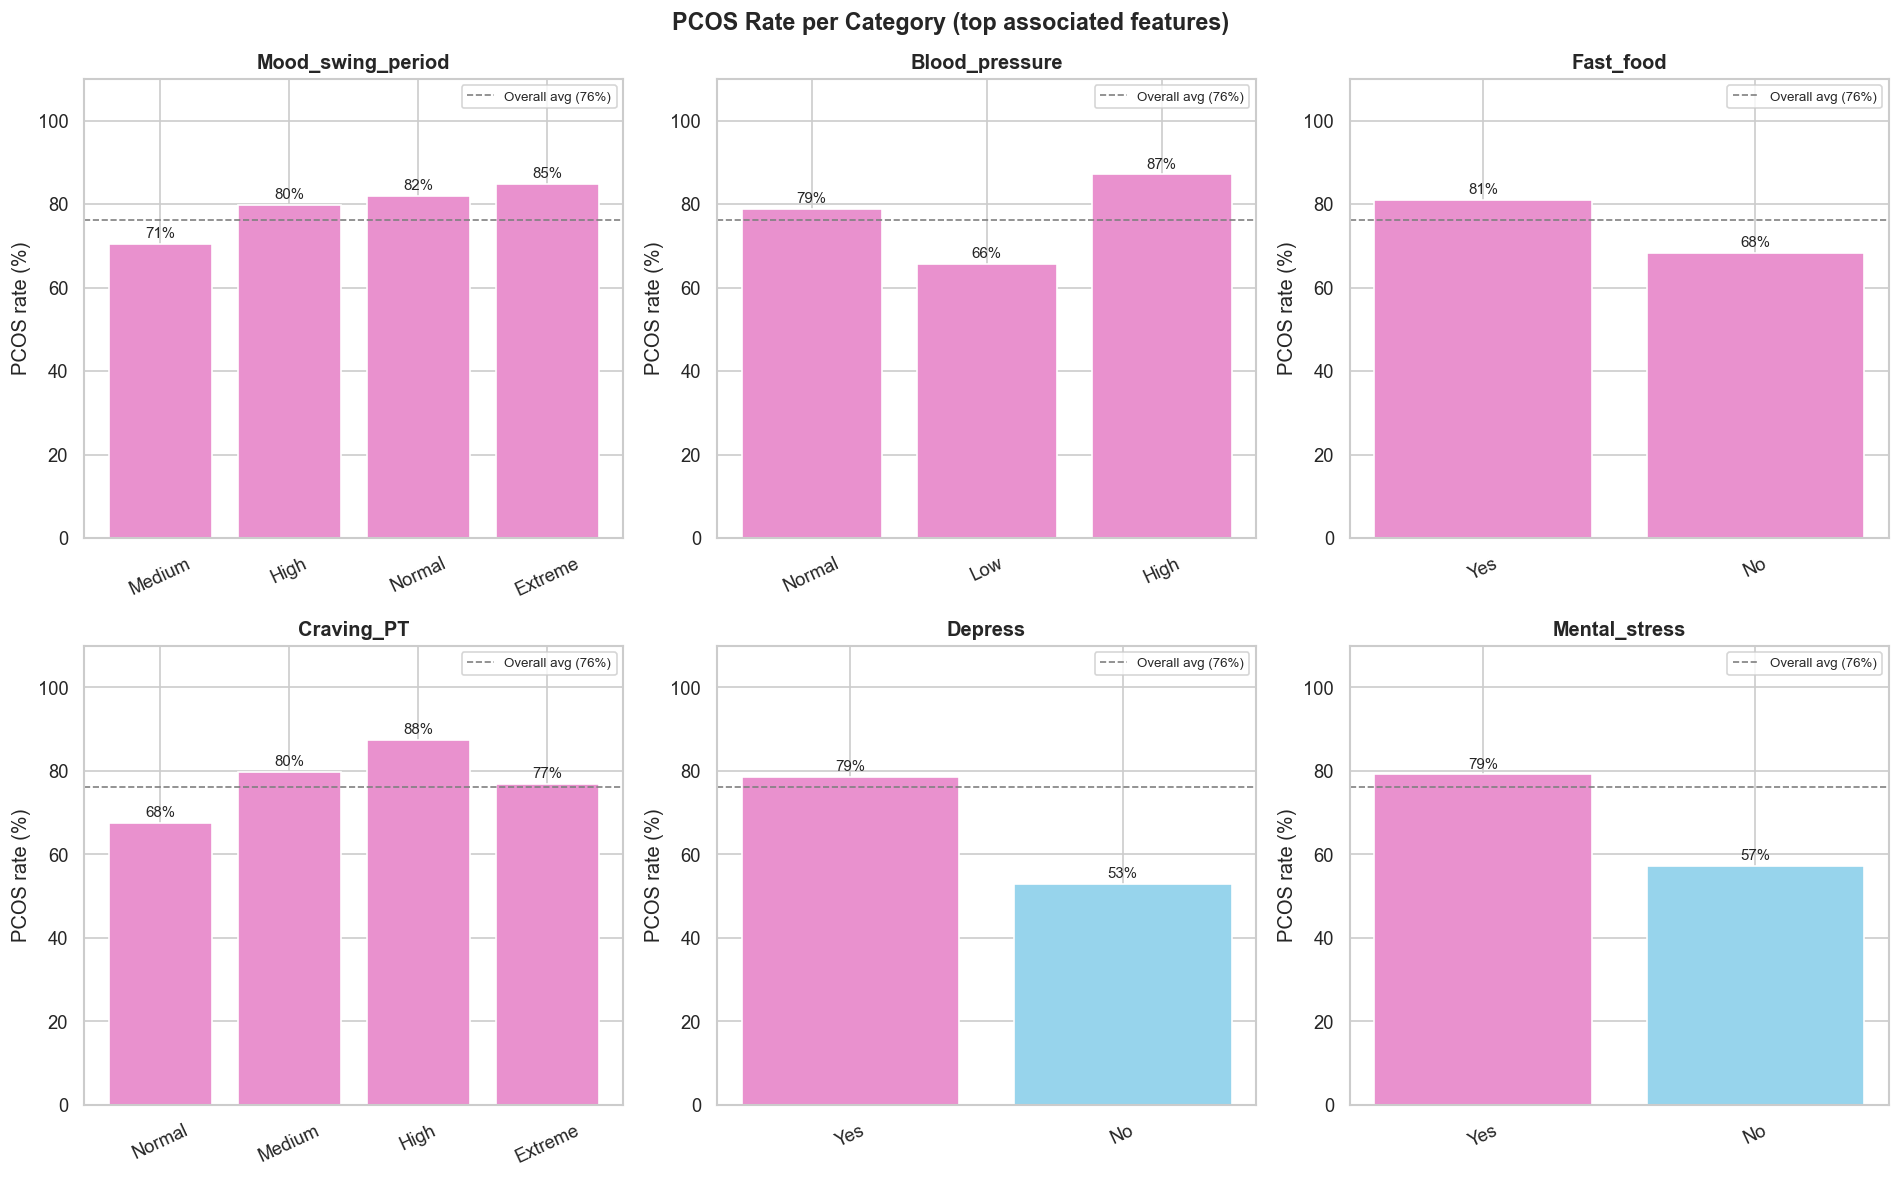

In [18]:
high_cv = cv_df[cv_df["Cramers_V"] >= 0.1].index.tolist()[:6]  # top features

n_cols_t = 3
n_rows_t = (len(high_cv) + n_cols_t - 1) // n_cols_t

fig, axes = plt.subplots(n_rows_t, n_cols_t, figsize=(16, 5 * n_rows_t))
axes = axes.flatten()

for idx, col in enumerate(high_cv):
    ax = axes[idx]
    order = df[col].value_counts().index.tolist()
    pcos_rate = df.groupby(col)[target].mean().reindex(order) * 100
    bars = ax.bar(pcos_rate.index, pcos_rate.values,
                  color=["#E991CE" if v > 60 else "#97D4EC" for v in pcos_rate.values])
    ax.axhline(df[target].mean() * 100, color="gray", linestyle="--",
               linewidth=1, label=f"Overall avg ({df[target].mean()*100:.0f}%)")
    ax.set_ylim(0, 110)
    ax.set_ylabel("PCOS rate (%)")
    ax.set_title(f"{col}")
    ax.legend(fontsize=8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f"{bar.get_height():.0f}%", ha="center", fontsize=9)
    ax.tick_params(axis="x", rotation=25)

for idx in range(len(high_cv), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("PCOS Rate per Category (top associated features)", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


## 11. Correlation Heatmap (Numerical)

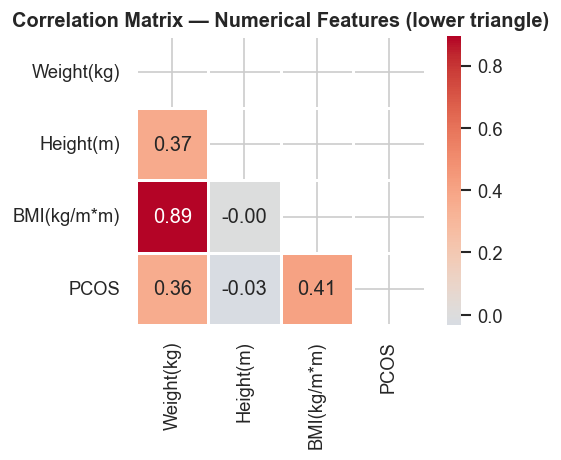

In [19]:
corr = df[numerical_cols + [target]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.8, mask=mask)
plt.title("Correlation Matrix — Numerical Features (lower triangle)")
plt.tight_layout()
plt.show()


## 12. EDA Summary & Next Steps

In [20]:
print("=" * 60)
print("EDA SUMMARY — SYMPTOMS DATASET")
print("=" * 60)
print(f"  Rows after cleaning      : {len(df)}")
print(f"  Features (numerical)     : {len(numerical_cols)}")
print(f"  Features (categorical)   : {len(cat_cols)}")
print()
print("DATA QUALITY NOTES:")
print("  ✓ Column name spaces stripped")
print("  ✓ 2 rows with Height=0 / BMI=0 dropped")
print("  ✓ Hormonal_imbalance dirty value '2' replaced with mode")
print("  ✓ Cyst_ovary casing standardised")
print()
print("FEATURE ENGINEERING TASKS (for 02_features notebook):")
print("  → Encode 'I do not know' (high freq 20-37%): treat as separate ordinal level")
print("  → Binary encode: Yes/No columns")
print("  → Ordinal encode: Mood_swing, Craving_PT (Normal/Medium/High/Extreme)")
print("  → Handle class imbalance with SMOTE or class_weight='balanced'")
print("  → Consider dropping or grouping low Cramér's V features")


EDA SUMMARY — SYMPTOMS DATASET
  Rows after cleaning      : 682
  Features (numerical)     : 3
  Features (categorical)   : 29

DATA QUALITY NOTES:
  ✓ Column name spaces stripped
  ✓ 2 rows with Height=0 / BMI=0 dropped
  ✓ Hormonal_imbalance dirty value '2' replaced with mode
  ✓ Cyst_ovary casing standardised

FEATURE ENGINEERING TASKS (for 02_features notebook):
  → Encode 'I do not know' (high freq 20-37%): treat as separate ordinal level
  → Binary encode: Yes/No columns
  → Ordinal encode: Mood_swing, Craving_PT (Normal/Medium/High/Extreme)
  → Handle class imbalance with SMOTE or class_weight='balanced'
  → Consider dropping or grouping low Cramér's V features
